In [1]:
import EFC_learningfMRI.globals as gl
import os
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np
from EFC_learningfMRI.vis import plot_im_sess
from EFC_learningfMRI.util import ttest_im_sess
import warnings

# warnings.filterwarnings('ignore')

base directory found: /cifs/diedrichsen/data/Chord_exp/EFC_learningfMRI
Atlas directory found: atlases
figure directory found: figures/


In [2]:
H             = 'L'
atlas         = 'ROI'
rois          = gl.rois[atlas]
glm           = 3
ref_session   = 3
hue_order     = ['trained', 'untrained']
palette       = ['red', 'blue']

# Session 3 group geometry
The group reference used by the models below: the across-participant mean dissimilarity of each chord pair in session 3 (the `*_group` columns), with chords in `gl.chordID` order.

In [3]:
dist = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity.within_session.{atlas}.glm{glm}.tsv'), sep='\t')
dist = dist[dist.Hem==H]

# the *_group columns are one value per Hem/roi/pair, repeated on every row
group = dist.groupby(['roi', 'pair'])[['crossnobis_group', 'cosine_group']].first().reset_index()
group['theta_group'] = np.arccos(1 - group.cosine_group)  # cosine_group is 1 - cosine

K   = len(gl.chordID)
idx = {str(c): i for i, c in enumerate(gl.chordID)}

# one K x K matrix per ROI, chords in gl.chordID order
group_mats = {}
for metric in ['crossnobis_group', 'cosine_group', 'theta_group']:
    group_mats[metric] = np.zeros((len(rois), K, K))
    for m, roi in enumerate(rois):
        for _, row in group[group.roi == roi].iterrows():
            i, j = (idx[c] for c in row.pair.split('-'))
            group_mats[metric][m, i, j] = group_mats[metric][m, j, i] = row[metric]

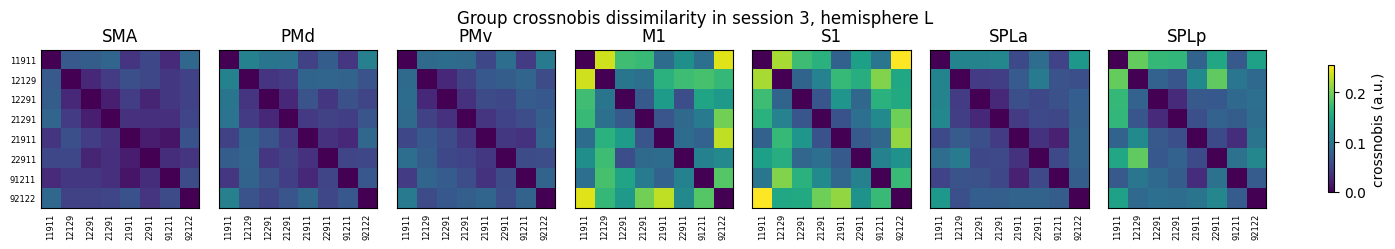

In [4]:
mats = group_mats['crossnobis_group']

fig, axs = plt.subplots(1, len(rois), figsize=(2 * len(rois), 2.3), constrained_layout=True)

for m, roi in enumerate(rois):
    ax = axs[m]
    im = ax.imshow(mats[m], cmap='viridis', vmin=0, vmax=mats.max())
    ax.set_xticks(range(K), gl.chordID, rotation=90, fontsize=6)
    ax.set_yticks(range(K), gl.chordID if m == 0 else [''] * K, fontsize=6)
    ax.tick_params(length=0)
    ax.set_title(roi)

fig.colorbar(im, ax=axs, label='crossnobis (a.u.)', shrink=.8)

fig.suptitle(f'Group crossnobis dissimilarity in session {ref_session}, hemisphere {H}')

plt.show()

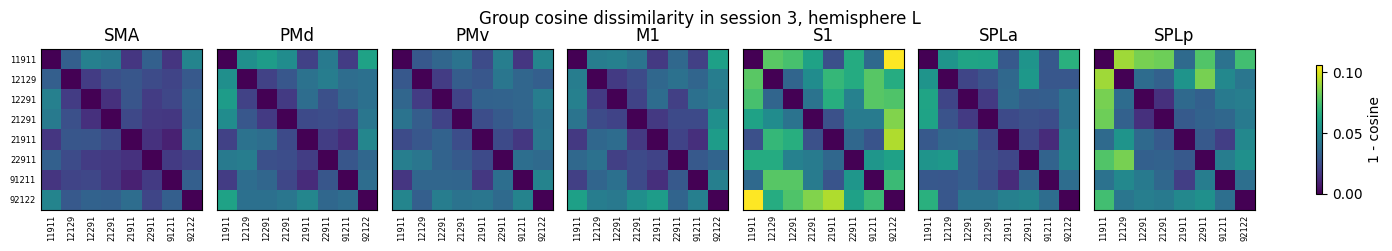

In [5]:
mats = group_mats['cosine_group']

fig, axs = plt.subplots(1, len(rois), figsize=(2 * len(rois), 2.3), constrained_layout=True)

for m, roi in enumerate(rois):
    ax = axs[m]
    im = ax.imshow(mats[m], cmap='viridis', vmin=0, vmax=mats.max())
    ax.set_xticks(range(K), gl.chordID, rotation=90, fontsize=6)
    ax.set_yticks(range(K), gl.chordID if m == 0 else [''] * K, fontsize=6)
    ax.tick_params(length=0)
    ax.set_title(roi)

fig.colorbar(im, ax=axs, label='1 - cosine', shrink=.8)

fig.suptitle(f'Group cosine dissimilarity in session {ref_session}, hemisphere {H}')

plt.show()

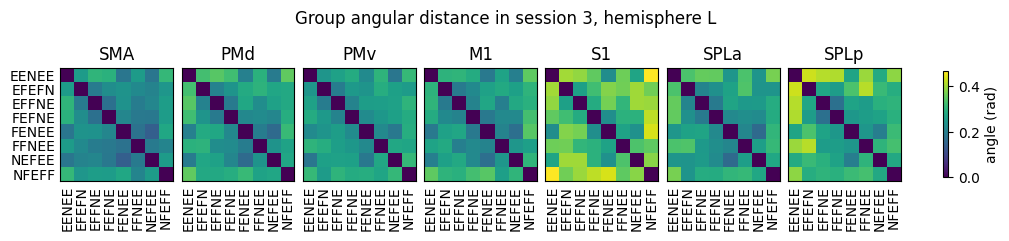

In [26]:
mats = group_mats['theta_group']

fig, axs = plt.subplots(1, len(rois), figsize=(10, 2.3), constrained_layout=True)

for m, roi in enumerate(rois):
    ax = axs[m]
    im = ax.imshow(mats[m], cmap='viridis', vmin=0, vmax=mats.max())
    ax.set_xticks(range(K), gl.chordLabel, rotation=90)
    ax.set_yticks(range(K), gl.chordLabel if m == 0 else [''] * K)
    ax.tick_params(length=0)
    ax.set_title(roi)

fig.colorbar(im, ax=axs, label='angle (rad)', shrink=.6)

fig.suptitle(f'Group angular distance in session {ref_session}, hemisphere {H}')

fig.savefig('figures/group_angular_distance.pdf')

plt.show()

# Distances adjusted based on group geometry on session 3
For 8 chords, there are 70 possible sets of trained and untrained chords. While each chord was trained in half participants and untrained in the other half, the combination of trained and untrained chords was unique in each participants. Because we only collected N=16 participants, we could not sample all the possible combinations. Therefore, is possible that the underlying geometry in each participant influences the mean distances. To account for this, we regressed out the mean geometry at session 3 across participants from the crossnobis and cosine dissimilarities in each session, as follows:

...

adjusted for group
           T  dof     p_val           CI95   roi  session
0  -0.047005   15  0.963129  [-0.02, 0.02]   SMA        3
3  -0.019706   15  0.984537  [-0.02, 0.02]   PMd        3
6  -0.282921   15  0.781104  [-0.03, 0.02]   PMv        3
9  -0.687784   15  0.502086  [-0.04, 0.02]    M1        3
12 -0.544281   15  0.594247  [-0.03, 0.02]    S1        3
15 -0.968531   15  0.348138  [-0.04, 0.02]  SPLa        3
18 -0.746256   15  0.467048  [-0.04, 0.02]  SPLp        3
1   0.492129   15  0.629753  [-0.02, 0.03]   SMA        9
4  -1.015461   15  0.325986  [-0.03, 0.01]   PMd        9
7   0.003448   15  0.997295  [-0.03, 0.03]   PMv        9
10  0.682981   15  0.505031  [-0.03, 0.06]    M1        9
13  1.327131   15  0.204313  [-0.01, 0.05]    S1        9
16  0.301738   15  0.766995  [-0.02, 0.03]  SPLa        9
19  0.129909   15  0.898365  [-0.02, 0.02]  SPLp        9
2  -0.106022   15  0.916970  [-0.02, 0.02]   SMA       23
5  -0.017038   15  0.986631  [-0.02, 0.02]   PMd     

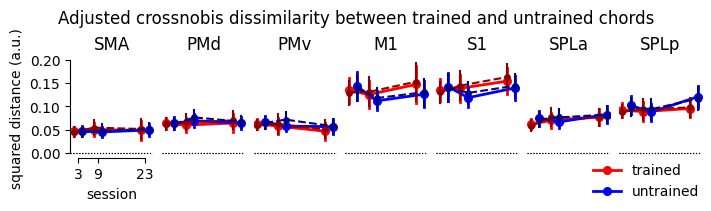

In [7]:
# adjusted for the group geometry only, and for the group + the subject's own force (der) geometry
dist_ancova = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity_ancova.within_session.ROI.glm{glm}.tsv'), sep='\t')
dist_ancova = dist_ancova[dist_ancova.Hem==H]
dist_chord_sess_ancova = dist_ancova.groupby(['sn', 'Hem', 'roi', 'session', 'chord']).mean(numeric_only=True).reset_index()

dist_ancova_force = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity_ancova_force.der.within_session.ROI.glm{glm}.tsv'), sep='\t')
dist_ancova_force = dist_ancova_force[dist_ancova_force.Hem==H]
dist_chord_sess_ancova_force = dist_ancova_force.groupby(['sn', 'Hem', 'roi', 'session', 'chord']).mean(numeric_only=True).reset_index()

adjusted = {'group': dist_chord_sess_ancova, 'group + force': dist_chord_sess_ancova_force}

# group only: solid; group + force: dotted, narrower
linestyle = {'group': dict(ls='-', lw=2), 'group + force': dict(ls='--', lw=1.5)}
palette_ancova = {'group': palette, 'group + force': ['darkred', 'darkblue']}

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

for a, (label, df) in enumerate(adjusted.items()):
        plot_im_sess(fig, axs, df, rois, y='crossnobis', x='session', hue='chord', hue_order=hue_order, palette=palette_ancova[label], kind='point', estimator='mean', dodge=.4, add_zero=True, legend=a==0, **linestyle[label])

        ttest = ttest_im_sess(df, rois, y='crossnobis', x='session', hue='chord', hue_order=hue_order)
        ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
        ttest.sort_values(by=['session', 'roi'], inplace=True)

        print(f'adjusted for {label}')
        print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('squared distance (a.u.)')
axs[0].set_xlabel('session')

fig.suptitle('Adjusted crossnobis dissimilarity between trained and untrained chords')

plt.show()


adjusted for group
           T  dof     p_val           CI95   roi  session
0   0.047695   15  0.962589  [-0.01, 0.01]   SMA        3
3   0.649123   15  0.526074  [-0.01, 0.01]   PMd        3
6  -0.496184   15  0.626956  [-0.01, 0.01]   PMv        3
9  -0.526338   15  0.606349  [-0.01, 0.01]    M1        3
12  0.139487   15  0.890921  [-0.01, 0.01]    S1        3
15 -0.382232   15  0.707651  [-0.01, 0.01]  SPLa        3
18 -0.070718   15  0.944557  [-0.01, 0.01]  SPLp        3
1   0.422316   15  0.678785  [-0.01, 0.01]   SMA        9
4   0.456472   15  0.654591  [-0.01, 0.02]   PMd        9
7   0.586804   15  0.566063  [-0.01, 0.02]   PMv        9
10  0.251634   15  0.804739  [-0.01, 0.01]    M1        9
13  1.597051   15  0.131103   [-0.0, 0.03]    S1        9
16  1.539414   15  0.144530   [-0.0, 0.02]  SPLa        9
19  0.104362   15  0.918265  [-0.01, 0.02]  SPLp        9
2   0.622662   15  0.542858  [-0.01, 0.02]   SMA       23
5   1.286508   15  0.217768   [-0.0, 0.02]   PMd     

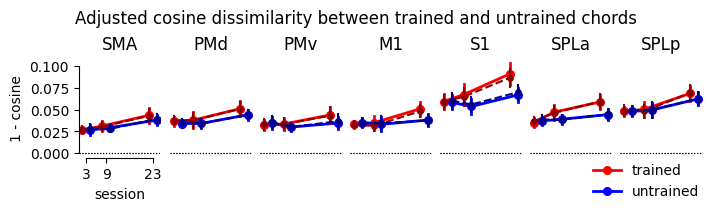

In [8]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

for a, (label, df) in enumerate(adjusted.items()):
        plot_im_sess(fig, axs, df, rois, y='cosine', x='session', hue='chord', hue_order=hue_order, palette=palette_ancova[label], kind='point', estimator='mean', dodge=.4, add_zero=True, legend=a==0, **linestyle[label])

        ttest = ttest_im_sess(df, rois, y='cosine', x='session', hue='chord', hue_order=hue_order)
        ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
        ttest.sort_values(by=['session', 'roi'], inplace=True)

        print(f'adjusted for {label}')
        print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('1 - cosine')
axs[0].set_xlabel('session')

fig.suptitle('Adjusted cosine dissimilarity between trained and untrained chords')

plt.show()


/home/UWO/memanue5/Documents/GitHub/EFC_learningfMRI/venv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/UWO/memanue5/Documents/GitHub/EFC_learningfMRI/venv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)


adjusted for group
           T  dof     p_val           CI95   roi  session
0   0.414369   15  0.684469  [-0.04, 0.06]   SMA        3
3   0.502207   15  0.622814  [-0.03, 0.04]   PMd        3
6  -0.191689   15  0.850556  [-0.05, 0.04]   PMv        3
9  -0.091182   15  0.928555  [-0.03, 0.03]    M1        3
12  0.340589   15  0.738136  [-0.03, 0.04]    S1        3
15 -0.686007   15  0.503175  [-0.05, 0.03]  SPLa        3
18 -0.182000   15  0.858019  [-0.04, 0.04]  SPLp        3
1  -0.044943   15  0.964746  [-0.04, 0.03]   SMA        9
4   0.312257   14  0.759448  [-0.04, 0.06]   PMd        9
7   0.151451   15  0.881638  [-0.05, 0.05]   PMv        9
10  0.441134   15  0.665408  [-0.03, 0.05]    M1        9
13  1.611787   15  0.127845  [-0.01, 0.08]    S1        9
16  1.475009   14  0.162342  [-0.01, 0.06]  SPLa        9
19  0.409784   14  0.688166  [-0.03, 0.05]  SPLp        9
2   0.223366   15  0.826264  [-0.06, 0.07]   SMA       23
5   0.977547   15  0.343802  [-0.02, 0.05]   PMd     

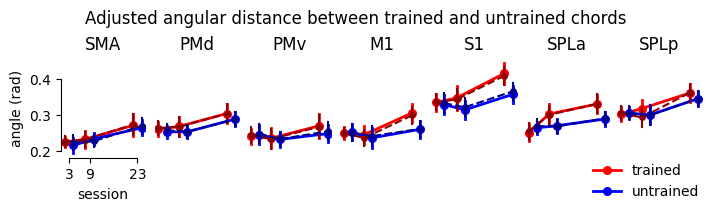

In [9]:
for df in adjusted.values():
        df['theta'] = np.arccos(1 - df.cosine)

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

for a, (label, df) in enumerate(adjusted.items()):
        plot_im_sess(fig, axs, df, rois, y='theta', x='session', hue='chord', hue_order=hue_order, palette=palette_ancova[label], kind='point', estimator='mean', dodge=.4, add_zero=False, legend=a==0, **linestyle[label])

        ttest = ttest_im_sess(df, rois, y='theta', x='session', hue='chord', hue_order=hue_order)
        ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
        ttest.sort_values(by=['session', 'roi'], inplace=True)

        print(f'adjusted for {label}')
        print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])
        print('\n')

axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('angle (rad)')
axs[0].set_xlabel('session')

fig.suptitle('Adjusted angular distance between trained and untrained chords')

fig.savefig('figures/aagj_ngle_mean.pdf')

plt.show()


/tmp/ipykernel_1063321/2900208366.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(frameon=False, loc='lower right')


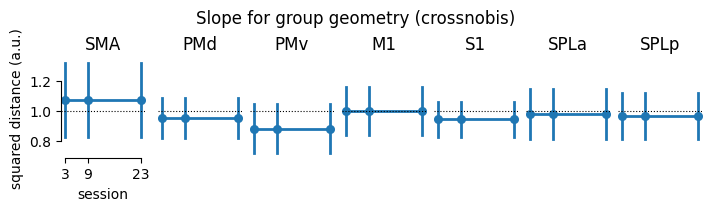

In [10]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, dist_chord_sess_ancova, rois, y='crossnobis_slope_group', x='session', kind='point', estimator='mean', dodge=.4, add_zero=1)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('squared distance (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Slope for group geometry (crossnobis)')

plt.show()

/tmp/ipykernel_1063321/2445312358.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(frameon=False, loc='lower right')


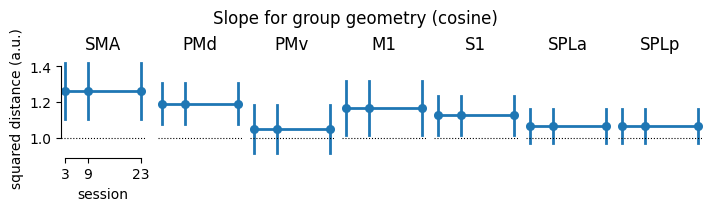

In [11]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, dist_chord_sess_ancova, rois, y='cosine_slope_group', x='session', kind='point', estimator='mean', dodge=.4, add_zero=1)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('squared distance (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Slope for group geometry (cosine)')

plt.show()

## Force slope
In the group + force model, the slope of the participant's own force (der) geometry, fit separately in each session; one-sample t-test against zero per ROI and session.

crossnobis
           T  dof     p_val           CI95   roi  session
0   2.212336   15  0.042873    [0.0, 0.04]   SMA        3
3   2.837302   15  0.012483   [0.01, 0.05]   PMd        3
6   2.530051   15  0.023093    [0.0, 0.05]   PMv        3
9   2.065552   15  0.056598   [-0.0, 0.13]    M1        3
12  3.014172   15  0.008717   [0.02, 0.12]    S1        3
15  2.762140   15  0.014527   [0.01, 0.05]  SPLa        3
18  2.119826   15  0.051110   [-0.0, 0.06]  SPLp        3
1   0.959567   15  0.352486  [-0.02, 0.06]   SMA        9
4   3.048595   15  0.008127   [0.02, 0.12]   PMd        9
7   1.832901   15  0.086740  [-0.01, 0.14]   PMv        9
10  2.852746   15  0.012099   [0.02, 0.17]    M1        9
13  2.547500   15  0.022308   [0.02, 0.18]    S1        9
16  3.209984   15  0.005843   [0.03, 0.13]  SPLa        9
19  2.174154   15  0.046111    [0.0, 0.11]  SPLp        9
2   0.670749   15  0.512577  [-0.01, 0.03]   SMA       23
5   2.757692   15  0.014658   [0.01, 0.07]   PMd       23
8  

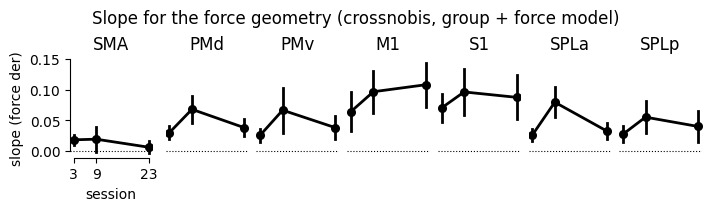

cosine
           T  dof     p_val           CI95   roi  session
0  -0.213557   15  0.833768  [-0.14, 0.11]   SMA        3
3   0.098190   15  0.923082    [-0.1, 0.1]   PMd        3
6   0.426903   15  0.675514  [-0.08, 0.12]   PMv        3
9  -0.138035   15  0.892048  [-0.11, 0.09]    M1        3
12  0.743380   15  0.468736    [-0.1, 0.2]    S1        3
15  0.182928   15  0.857304  [-0.12, 0.14]  SPLa        3
18  1.098447   15  0.289329  [-0.05, 0.15]  SPLp        3
1   2.095742   15  0.053482   [-0.0, 0.17]   SMA        9
4   2.181578   15  0.045464    [0.0, 0.14]   PMd        9
7  -0.155916   15  0.878178  [-0.05, 0.04]   PMv        9
10  3.488481   15  0.003301   [0.07, 0.27]    M1        9
13  2.932158   15  0.010300   [0.06, 0.35]    S1        9
16  4.048199   15  0.001051   [0.08, 0.26]  SPLa        9
19  2.185325   15  0.045141    [0.0, 0.29]  SPLp        9
2   1.261618   15  0.226353  [-0.04, 0.17]   SMA       23
5   1.915785   15  0.074653   [-0.01, 0.2]   PMd       23
8   1.7

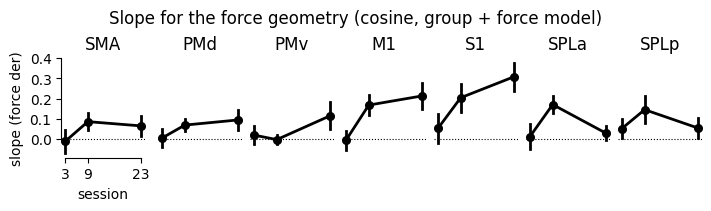

In [12]:
# one slope per participant, ROI and session
slope_force = dist_ancova_force.groupby(['sn', 'roi', 'session'])[['crossnobis_slope_force_der', 'cosine_slope_force_der']].first().reset_index()

for metric in ['crossnobis', 'cosine']:
    y = f'{metric}_slope_force_der'

    fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

    plot_im_sess(fig, axs, slope_force, rois, y=y, x='session', color='k', kind='point', estimator='mean', add_zero=True)
    sb.despine(ax=axs[0], trim=True)
    axs[0].set_ylabel('slope (force der)')
    axs[0].set_xlabel('session')

    ttest = ttest_im_sess(slope_force, rois, y=y, x='session')
    ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
    ttest.sort_values(by=['session', 'roi'], inplace=True)
    print(metric)
    print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

    fig.suptitle(f'Slope for the force geometry ({metric}, group + force model)')

    plt.show()

# Neural geometry predicted from the force geometry
In each participant, hemisphere and ROI, the neural dissimilarities between chord pairs in session 3 were regressed on the force dissimilarities of the same pairs (intercept + slope; crossnobis on crossnobis, cosine on cosine), separately for absolute force (`abs`) and force derivative (`der`). The fitted model was then used to predict the neural dissimilarities of every session from that session's force dissimilarities. The residual (observed − predicted) is the part of the neural geometry that the force geometry does not account for. Session 3 is the fitting session, so its residuals are in-sample and average to zero across trained and untrained pairs.

In [13]:
pred = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity_force_prediction.ref{ref_session}.within_session.{atlas}.glm{glm}.tsv'), sep='\t')
pred = pred[pred.Hem==H]
pred_chord_sess = pred.groupby(['sn', 'Hem', 'roi', 'force_metric', 'session', 'chord']).mean(numeric_only=True).reset_index()

## Crossnobis

           T  dof     p_val           CI95   roi  session
0  -0.683861   15  0.504491  [-0.02, 0.01]   SMA        3
3  -0.414590   15  0.684311  [-0.02, 0.01]   PMd        3
6  -0.503750   15  0.621754  [-0.03, 0.02]   PMv        3
9  -0.451980   15  0.657751  [-0.05, 0.03]    M1        3
12 -0.503882   15  0.621664  [-0.03, 0.02]    S1        3
15 -1.089541   15  0.293110  [-0.04, 0.01]  SPLa        3
18 -0.700506   15  0.494335  [-0.04, 0.02]  SPLp        3
1   0.057417   15  0.954971  [-0.02, 0.02]   SMA        9
4  -1.183841   15  0.254898  [-0.04, 0.01]   PMd        9
7  -0.231206   15  0.820279  [-0.03, 0.02]   PMv        9
10  0.196183   15  0.847100  [-0.04, 0.05]    M1        9
13  0.744591   15  0.468025  [-0.03, 0.06]    S1        9
16  0.066060   15  0.948202  [-0.02, 0.02]  SPLa        9
19 -0.113349   15  0.911257  [-0.02, 0.02]  SPLp        9
2  -0.408703   15  0.688533  [-0.01, 0.01]   SMA       23
5  -0.291638   15  0.774558  [-0.02, 0.01]   PMd       23
8  -1.559964  

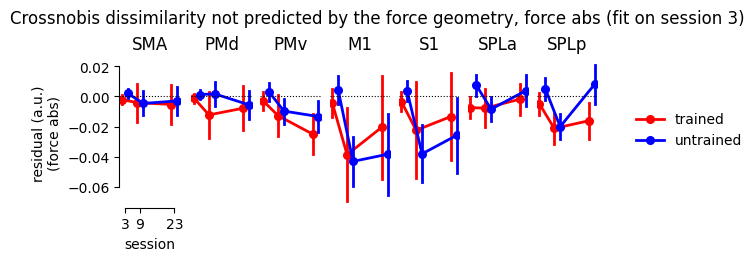

In [14]:
force_metric = 'abs'

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2.5), constrained_layout=True)

df = pred_chord_sess[pred_chord_sess.force_metric == force_metric]
plot_im_sess(fig, axs, df, rois, y='crossnobis_resid', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=True, legend=True)
axs[0].set_ylabel(f'residual (a.u.)\n(force {force_metric})')

ttest = ttest_im_sess(df, rois, y='crossnobis_resid', x='session', hue='chord', hue_order=hue_order)
ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
ttest.sort_values(by=['session', 'roi'], inplace=True)
print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

for ax in axs.flat:
    ax.legend([], frameon=False)
fig.legend(frameon=False, loc='outside right center')
sb.despine(ax=axs[0], trim=True)
axs[0].set_xlabel('session')

fig.suptitle(f'Crossnobis dissimilarity not predicted by the force geometry, force {force_metric} (fit on session {ref_session})')

fig.savefig(f'figures/crossnobis_force_prediction_resid.{force_metric}.ref{ref_session}.pdf')

plt.show()

           T  dof     p_val            CI95   roi  session
0  -0.883868   15  0.390714   [-0.02, 0.01]   SMA        3
3  -0.665202   15  0.516019   [-0.02, 0.01]   PMd        3
6  -0.880033   15  0.392723   [-0.03, 0.01]   PMv        3
9  -0.664995   15  0.516148   [-0.04, 0.02]    M1        3
12 -1.027947   15  0.320266   [-0.04, 0.02]    S1        3
15 -1.493708   15  0.155988   [-0.05, 0.01]  SPLa        3
18 -1.399717   15  0.181939   [-0.05, 0.01]  SPLp        3
1  -0.091869   15  0.928018   [-0.02, 0.02]   SMA        9
4  -1.201821   15  0.248064   [-0.04, 0.01]   PMd        9
7  -0.114180   15  0.910610   [-0.03, 0.03]   PMv        9
10  0.199769   15  0.844344   [-0.04, 0.05]    M1        9
13  0.468742   15  0.645994   [-0.03, 0.05]    S1        9
16 -0.293125   15  0.773443   [-0.03, 0.02]  SPLa        9
19 -0.304281   15  0.765094   [-0.03, 0.02]  SPLp        9
2  -0.953789   15  0.355309   [-0.02, 0.01]   SMA       23
5  -0.623276   15  0.542465   [-0.02, 0.01]   PMd       

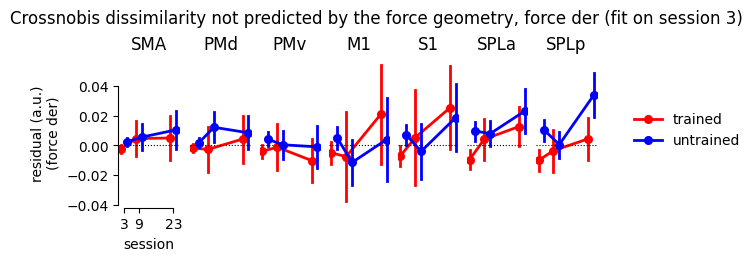

In [15]:
force_metric = 'der'

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2.5), constrained_layout=True)

df = pred_chord_sess[pred_chord_sess.force_metric == force_metric]
plot_im_sess(fig, axs, df, rois, y='crossnobis_resid', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=True, legend=True)
axs[0].set_ylabel(f'residual (a.u.)\n(force {force_metric})')

ttest = ttest_im_sess(df, rois, y='crossnobis_resid', x='session', hue='chord', hue_order=hue_order)
ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
ttest.sort_values(by=['session', 'roi'], inplace=True)
print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

for ax in axs.flat:
    ax.legend([], frameon=False)
fig.legend(frameon=False, loc='outside right center')
sb.despine(ax=axs[0], trim=True)
axs[0].set_xlabel('session')

fig.suptitle(f'Crossnobis dissimilarity not predicted by the force geometry, force {force_metric} (fit on session {ref_session})')

fig.savefig(f'figures/crossnobis_force_prediction_resid.{force_metric}.ref{ref_session}.pdf')

plt.show()

## Cosine

           T  dof     p_val           CI95   roi  session
0  -0.564451   15  0.580790  [-0.01, 0.01]   SMA        3
3  -0.112413   15  0.911986  [-0.01, 0.01]   PMd        3
6  -0.502879   15  0.622352  [-0.01, 0.01]   PMv        3
9  -0.706543   15  0.490681  [-0.01, 0.01]    M1        3
12 -0.480394   15  0.637878  [-0.02, 0.01]    S1        3
15 -0.457885   15  0.653598  [-0.02, 0.01]  SPLa        3
18 -0.555192   15  0.586948  [-0.02, 0.01]  SPLp        3
1  -0.643441   15  0.529653  [-0.01, 0.01]   SMA        9
4  -0.249628   15  0.806261  [-0.01, 0.01]   PMd        9
7   0.230415   15  0.820882  [-0.01, 0.01]   PMv        9
10 -0.437623   15  0.667895  [-0.02, 0.01]    M1        9
13  1.061621   15  0.305202  [-0.01, 0.02]    S1        9
16  1.350990   15  0.196726   [-0.0, 0.01]  SPLa        9
19 -0.872275   15  0.396806  [-0.01, 0.01]  SPLp        9
2   0.257438   15  0.800339  [-0.01, 0.02]   SMA       23
5   0.551539   15  0.589387  [-0.01, 0.01]   PMd       23
8   1.206767  

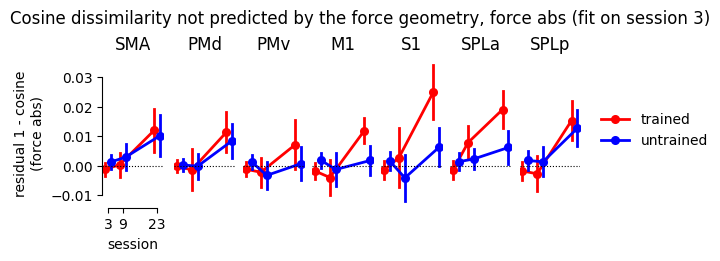

In [16]:
force_metric = 'abs'

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2.5), constrained_layout=True)

df = pred_chord_sess[pred_chord_sess.force_metric == force_metric]
plot_im_sess(fig, axs, df, rois, y='cosine_resid', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=True, legend=True)
axs[0].set_ylabel(f'residual 1 - cosine\n(force {force_metric})')

ttest = ttest_im_sess(df, rois, y='cosine_resid', x='session', hue='chord', hue_order=hue_order)
ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
ttest.sort_values(by=['session', 'roi'], inplace=True)
print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

for ax in axs.flat:
    ax.legend([], frameon=False)
fig.legend(frameon=False, loc='outside right center')
sb.despine(ax=axs[0], trim=True)
axs[0].set_xlabel('session')

fig.suptitle(f'Cosine dissimilarity not predicted by the force geometry, force {force_metric} (fit on session {ref_session})')

fig.savefig(f'figures/cosine_force_prediction_resid.{force_metric}.ref{ref_session}.pdf')

plt.show()

           T  dof     p_val           CI95   roi  session
0  -0.830803   15  0.419113  [-0.01, 0.01]   SMA        3
3  -0.104209   15  0.918384  [-0.01, 0.01]   PMd        3
6  -0.498885   15  0.625097  [-0.01, 0.01]   PMv        3
9  -0.943176   15  0.360535  [-0.02, 0.01]    M1        3
12 -0.721103   15  0.481935  [-0.02, 0.01]    S1        3
15 -0.641305   15  0.531002  [-0.01, 0.01]  SPLa        3
18 -0.616482   15  0.546819  [-0.01, 0.01]  SPLp        3
1  -0.631399   15  0.537283  [-0.01, 0.01]   SMA        9
4  -0.299830   15  0.768422  [-0.01, 0.01]   PMd        9
7   0.749040   15  0.465418  [-0.01, 0.01]   PMv        9
10 -0.179061   15  0.860286  [-0.01, 0.01]    M1        9
13  0.933662   15  0.365265  [-0.01, 0.02]    S1        9
16  0.796488   15  0.438174  [-0.01, 0.01]  SPLa        9
19 -0.844418   15  0.411702  [-0.02, 0.01]  SPLp        9
2   0.203089   15  0.841795  [-0.01, 0.02]   SMA       23
5   0.417342   15  0.682340  [-0.01, 0.01]   PMd       23
8   1.584808  

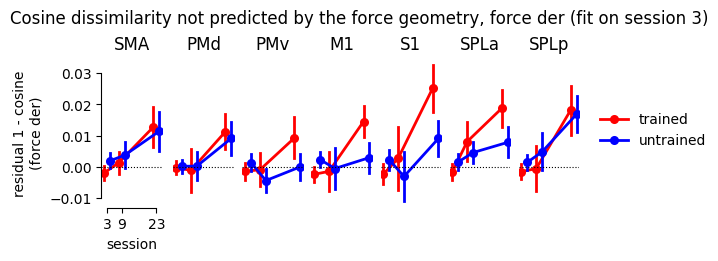

In [17]:
force_metric = 'der'

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2.5), constrained_layout=True)

df = pred_chord_sess[pred_chord_sess.force_metric == force_metric]
plot_im_sess(fig, axs, df, rois, y='cosine_resid', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=True, legend=True)
axs[0].set_ylabel(f'residual 1 - cosine\n(force {force_metric})')

ttest = ttest_im_sess(df, rois, y='cosine_resid', x='session', hue='chord', hue_order=hue_order)
ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
ttest.sort_values(by=['session', 'roi'], inplace=True)
print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

for ax in axs.flat:
    ax.legend([], frameon=False)
fig.legend(frameon=False, loc='outside right center')
sb.despine(ax=axs[0], trim=True)
axs[0].set_xlabel('session')

fig.suptitle(f'Cosine dissimilarity not predicted by the force geometry, force {force_metric} (fit on session {ref_session})')

fig.savefig(f'figures/cosine_force_prediction_resid.{force_metric}.ref{ref_session}.pdf')

plt.show()

# Neural geometry predicted from the force and the group geometry
As above, but with the session 3 group geometry (the across-participant mean dissimilarity of each chord pair in session 3) as a second covariate: neural ~ intercept + force + group, fit on session 3. The group term is the same in every session, so in sessions 9 and 23 it only contributes a fixed per-pair offset, and the change in the prediction comes from the force geometry alone.

In [18]:
pred_group = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity_force_group_prediction.ref{ref_session}.within_session.{atlas}.glm{glm}.tsv'), sep='\t')
pred_group = pred_group[pred_group.Hem==H]
pred_group_chord_sess = pred_group.groupby(['sn', 'Hem', 'roi', 'force_metric', 'session', 'chord']).mean(numeric_only=True).reset_index()

## Crossnobis

           T  dof     p_val           CI95   roi  session
0  -0.522798   15  0.608751  [-0.02, 0.01]   SMA        3
3  -0.599569   15  0.557742  [-0.01, 0.01]   PMd        3
6  -0.478220   15  0.639389  [-0.03, 0.02]   PMv        3
9  -1.375874   15  0.189058  [-0.05, 0.01]    M1        3
12 -1.045527   15  0.312336  [-0.04, 0.02]    S1        3
15 -0.973875   15  0.345563  [-0.03, 0.01]  SPLa        3
18 -0.701038   15  0.494012  [-0.03, 0.01]  SPLp        3
1   0.454761   15  0.655793  [-0.01, 0.02]   SMA        9
4  -1.224031   15  0.239819  [-0.03, 0.01]   PMd        9
7  -0.033152   15  0.973990  [-0.03, 0.03]   PMv        9
10 -0.061022   15  0.952148  [-0.05, 0.04]    M1        9
13  0.884920   15  0.390165  [-0.02, 0.05]    S1        9
16  1.100950   15  0.288273  [-0.01, 0.02]  SPLa        9
19  0.774800   15  0.450500  [-0.01, 0.02]  SPLp        9
2  -0.077224   15  0.939466  [-0.01, 0.01]   SMA       23
5  -0.085124   15  0.933288  [-0.02, 0.02]   PMd       23
8  -1.187581  

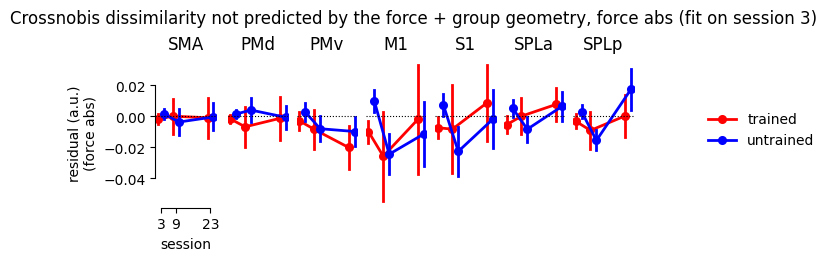

In [19]:
force_metric = 'abs'

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2.5), constrained_layout=True)

df = pred_group_chord_sess[pred_group_chord_sess.force_metric == force_metric]
plot_im_sess(fig, axs, df, rois, y='crossnobis_resid', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=True, legend=True)
axs[0].set_ylabel(f'residual (a.u.)\n(force {force_metric})')

ttest = ttest_im_sess(df, rois, y='crossnobis_resid', x='session', hue='chord', hue_order=hue_order)
ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
ttest.sort_values(by=['session', 'roi'], inplace=True)
print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

for ax in axs.flat:
    ax.legend([], frameon=False)
fig.legend(frameon=False, loc='outside right center')
sb.despine(ax=axs[0], trim=True)
axs[0].set_xlabel('session')

fig.suptitle(f'Crossnobis dissimilarity not predicted by the force + group geometry, force {force_metric} (fit on session {ref_session})')

fig.savefig(f'figures/crossnobis_force_group_prediction_resid.{force_metric}.ref{ref_session}.pdf')

plt.show()

           T  dof     p_val           CI95   roi  session
0  -0.640287   15  0.531646  [-0.01, 0.01]   SMA        3
3  -0.775866   15  0.449889  [-0.02, 0.01]   PMd        3
6  -0.993049   15  0.336436  [-0.03, 0.01]   PMv        3
9  -1.492186   15  0.156382  [-0.04, 0.01]    M1        3
12 -1.272198   15  0.222672  [-0.04, 0.01]    S1        3
15 -1.264508   15  0.225343  [-0.04, 0.01]  SPLa        3
18 -1.052190   15  0.309368  [-0.03, 0.01]  SPLp        3
1   0.200248   15  0.843976  [-0.02, 0.02]   SMA        9
4  -1.322053   15  0.205958  [-0.03, 0.01]   PMd        9
7  -0.141367   15  0.889461  [-0.03, 0.03]   PMv        9
10 -0.039635   15  0.968907  [-0.05, 0.04]    M1        9
13  0.503354   15  0.622026  [-0.03, 0.05]    S1        9
16  0.216381   15  0.831606  [-0.02, 0.02]  SPLa        9
19  0.718639   15  0.483409  [-0.01, 0.02]  SPLp        9
2  -0.553944   15  0.587781  [-0.02, 0.01]   SMA       23
5  -0.498509   15  0.625356  [-0.02, 0.01]   PMd       23
8  -1.467811  

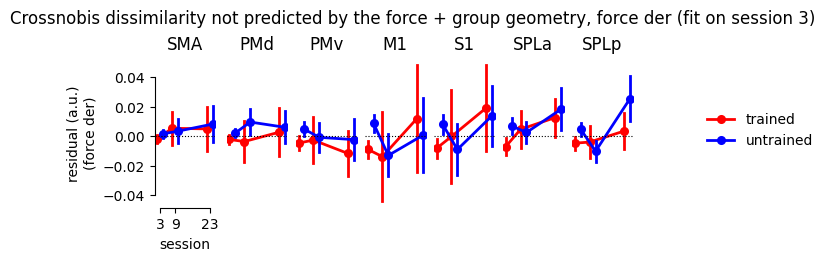

In [20]:
force_metric = 'der'

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2.5), constrained_layout=True)

df = pred_group_chord_sess[pred_group_chord_sess.force_metric == force_metric]
plot_im_sess(fig, axs, df, rois, y='crossnobis_resid', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=True, legend=True)
axs[0].set_ylabel(f'residual (a.u.)\n(force {force_metric})')

ttest = ttest_im_sess(df, rois, y='crossnobis_resid', x='session', hue='chord', hue_order=hue_order)
ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
ttest.sort_values(by=['session', 'roi'], inplace=True)
print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

for ax in axs.flat:
    ax.legend([], frameon=False)
fig.legend(frameon=False, loc='outside right center')
sb.despine(ax=axs[0], trim=True)
axs[0].set_xlabel('session')

fig.suptitle(f'Crossnobis dissimilarity not predicted by the force + group geometry, force {force_metric} (fit on session {ref_session})')

fig.savefig(f'figures/crossnobis_force_group_prediction_resid.{force_metric}.ref{ref_session}.pdf')

plt.show()

## Cosine

           T  dof     p_val           CI95   roi  session
0  -0.772812   15  0.451640  [-0.01, 0.01]   SMA        3
3  -0.293228   15  0.773365  [-0.01, 0.01]   PMd        3
6  -0.468223   15  0.646356  [-0.01, 0.01]   PMv        3
9  -0.967375   15  0.348696   [-0.01, 0.0]    M1        3
12 -0.375036   15  0.712883  [-0.01, 0.01]    S1        3
15 -0.533604   15  0.601434  [-0.01, 0.01]  SPLa        3
18 -0.288514   15  0.776902  [-0.01, 0.01]  SPLp        3
1  -0.700978   15  0.494049  [-0.01, 0.01]   SMA        9
4  -0.156079   15  0.878052  [-0.01, 0.01]   PMd        9
7   0.390305   15  0.701797  [-0.01, 0.01]   PMv        9
10 -0.207831   15  0.838157  [-0.01, 0.01]    M1        9
13  1.227904   15  0.238403  [-0.01, 0.03]    S1        9
16  1.845349   15  0.084820   [-0.0, 0.02]  SPLa        9
19 -0.140140   15  0.890414  [-0.01, 0.01]  SPLp        9
2   0.185218   15  0.855540  [-0.01, 0.02]   SMA       23
5   0.524138   15  0.607841  [-0.01, 0.01]   PMd       23
8   1.704406  

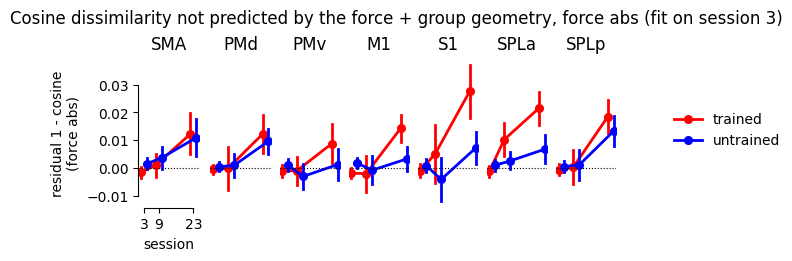

In [21]:
force_metric = 'abs'

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2.5), constrained_layout=True)

df = pred_group_chord_sess[pred_group_chord_sess.force_metric == force_metric]
plot_im_sess(fig, axs, df, rois, y='cosine_resid', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=True, legend=True)
axs[0].set_ylabel(f'residual 1 - cosine\n(force {force_metric})')

ttest = ttest_im_sess(df, rois, y='cosine_resid', x='session', hue='chord', hue_order=hue_order)
ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
ttest.sort_values(by=['session', 'roi'], inplace=True)
print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

for ax in axs.flat:
    ax.legend([], frameon=False)
fig.legend(frameon=False, loc='outside right center')
sb.despine(ax=axs[0], trim=True)
axs[0].set_xlabel('session')

fig.suptitle(f'Cosine dissimilarity not predicted by the force + group geometry, force {force_metric} (fit on session {ref_session})')

fig.savefig(f'figures/cosine_force_group_prediction_resid.{force_metric}.ref{ref_session}.pdf')

plt.show()

           T  dof     p_val           CI95   roi  session
0  -0.835653   15  0.416463  [-0.01, 0.01]   SMA        3
3  -0.272427   15  0.789008  [-0.01, 0.01]   PMd        3
6  -0.284535   15  0.779891  [-0.01, 0.01]   PMv        3
9  -1.062621   15  0.304763   [-0.01, 0.0]    M1        3
12 -0.485965   15  0.634015  [-0.01, 0.01]    S1        3
15 -0.494118   15  0.628380  [-0.01, 0.01]  SPLa        3
18 -0.630649   15  0.537761  [-0.01, 0.01]  SPLp        3
1  -0.352455   15  0.729400  [-0.01, 0.01]   SMA        9
4   0.038857   15  0.969517  [-0.01, 0.01]   PMd        9
7   0.824147   15  0.422768  [-0.01, 0.02]   PMv        9
10  0.130698   15  0.897751  [-0.01, 0.01]    M1        9
13  1.114461   15  0.282620  [-0.01, 0.03]    S1        9
16  1.682890   15  0.113089   [-0.0, 0.02]  SPLa        9
19  0.069107   15  0.945818  [-0.01, 0.01]  SPLp        9
2   0.329743   15  0.746154  [-0.01, 0.02]   SMA       23
5   0.869988   15  0.398015  [-0.01, 0.01]   PMd       23
8   2.172012  

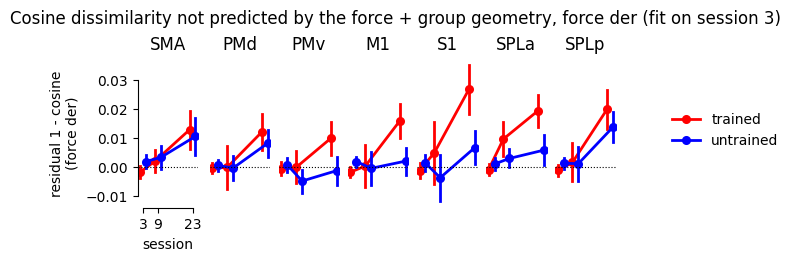

In [22]:
force_metric = 'der'

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2.5), constrained_layout=True)

df = pred_group_chord_sess[pred_group_chord_sess.force_metric == force_metric]
plot_im_sess(fig, axs, df, rois, y='cosine_resid', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=True, legend=True)
axs[0].set_ylabel(f'residual 1 - cosine\n(force {force_metric})')

ttest = ttest_im_sess(df, rois, y='cosine_resid', x='session', hue='chord', hue_order=hue_order)
ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
ttest.sort_values(by=['session', 'roi'], inplace=True)
print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

for ax in axs.flat:
    ax.legend([], frameon=False)
fig.legend(frameon=False, loc='outside right center')
sb.despine(ax=axs[0], trim=True)
axs[0].set_xlabel('session')

fig.suptitle(f'Cosine dissimilarity not predicted by the force + group geometry, force {force_metric} (fit on session {ref_session})')

fig.savefig(f'figures/cosine_force_group_prediction_resid.{force_metric}.ref{ref_session}.pdf')

plt.show()

In [23]:
pred_group_chord_sess['theta']       = np.arccos(1 - pred_group_chord_sess.cosine)
pred_group_chord_sess['theta_pred']  = np.arccos(1 - pred_group_chord_sess.cosine_pred)
pred_group_chord_sess['theta_resid'] = pred_group_chord_sess.theta - pred_group_chord_sess.theta_pred

           T  dof     p_val           CI95   roi  session
0  -0.351759   15  0.729912  [-0.04, 0.03]   SMA        3
3  -0.451886   15  0.657817  [-0.03, 0.02]   PMd        3
6  -0.305517   15  0.764171  [-0.04, 0.03]   PMv        3
9  -0.440932   15  0.665551  [-0.04, 0.03]    M1        3
12 -0.098441   15  0.922886  [-0.03, 0.03]    S1        3
15 -0.586812   15  0.566058  [-0.04, 0.02]  SPLa        3
18 -0.468583   15  0.646105  [-0.03, 0.02]  SPLp        3
1  -0.797698   15  0.437492  [-0.05, 0.02]   SMA        9
4  -0.555244   15  0.586914  [-0.06, 0.04]   PMd        9
7  -0.096083   15  0.924726  [-0.05, 0.04]   PMv        9
10 -0.069968   15  0.945143  [-0.05, 0.04]    M1        9
13  0.956413   15  0.354025  [-0.03, 0.07]    S1        9
16  1.155996   15  0.265764  [-0.02, 0.05]  SPLa        9
19 -0.049823   15  0.960921  [-0.04, 0.04]  SPLp        9
2  -0.092015   15  0.927904  [-0.06, 0.06]   SMA       23
5   0.453385   15  0.656761  [-0.03, 0.04]   PMd       23
8   0.888165  

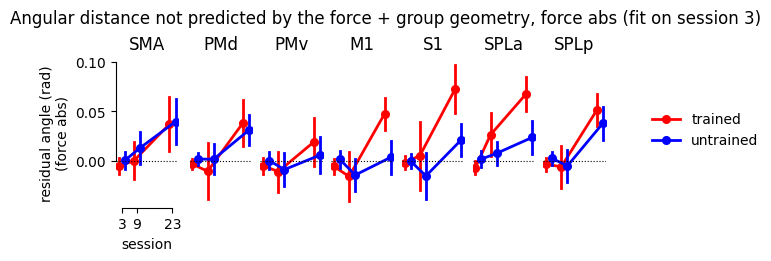

In [24]:
force_metric = 'abs'

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2.5), constrained_layout=True)

df = pred_group_chord_sess[pred_group_chord_sess.force_metric == force_metric]
plot_im_sess(fig, axs, df, rois, y='theta_resid', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=True, legend=True)
axs[0].set_ylabel(f'residual angle (rad)\n(force {force_metric})')

ttest = ttest_im_sess(df, rois, y='theta_resid', x='session', hue='chord', hue_order=hue_order)
ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
ttest.sort_values(by=['session', 'roi'], inplace=True)
print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

for ax in axs.flat:
    ax.legend([], frameon=False)
fig.legend(frameon=False, loc='outside right center')
sb.despine(ax=axs[0], trim=True)
axs[0].set_xlabel('session')

fig.suptitle(f'Angular distance not predicted by the force + group geometry, force {force_metric} (fit on session {ref_session})')

fig.savefig(f'figures/angle_force_group_prediction_resid.{force_metric}.ref{ref_session}.pdf')

plt.show()

           T  dof     p_val           CI95   roi  session
0  -0.447429   15  0.660959  [-0.04, 0.03]   SMA        3
3  -0.374601   15  0.713200  [-0.03, 0.02]   PMd        3
6  -0.222086   15  0.827242  [-0.04, 0.03]   PMv        3
9  -0.667407   15  0.514650  [-0.04, 0.02]    M1        3
12 -0.282487   15  0.781431  [-0.04, 0.03]    S1        3
15 -0.562000   15  0.582417  [-0.04, 0.02]  SPLa        3
18 -0.668555   15  0.513937  [-0.04, 0.02]  SPLp        3
1  -0.479336   15  0.638613  [-0.04, 0.03]   SMA        9
4  -0.434050   15  0.670431  [-0.05, 0.03]   PMd        9
7   0.273348   15  0.788313  [-0.04, 0.05]   PMv        9
10  0.380998   15  0.708547  [-0.04, 0.05]    M1        9
13  0.685707   15  0.503359  [-0.03, 0.06]    S1        9
16  1.042990   15  0.313472  [-0.02, 0.04]  SPLa        9
19  0.341744   15  0.737284  [-0.03, 0.05]  SPLp        9
2   0.109127   15  0.914548  [-0.05, 0.06]   SMA       23
5   0.807237   15  0.432145  [-0.02, 0.04]   PMd       23
8   1.503007  

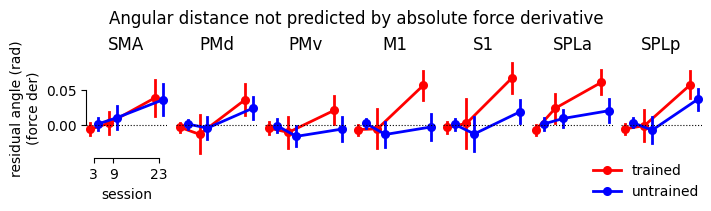

In [30]:
force_metric = 'der'

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

df = pred_group_chord_sess[pred_group_chord_sess.force_metric == force_metric]
plot_im_sess(fig, axs, df, rois, y='theta_resid', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=True, legend=True)
axs[0].set_ylabel(f'residual angle (rad)\n(force {force_metric})')

ttest = ttest_im_sess(df, rois, y='theta_resid', x='session', hue='chord', hue_order=hue_order)
ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
ttest.sort_values(by=['session', 'roi'], inplace=True)
print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
sb.despine(ax=axs[0], trim=True)
axs[0].set_xlabel('session')

fig.suptitle(f'Angular distance not predicted by absolute force derivative')

fig.savefig(f'figures/angle_force_group_prediction_resid.{force_metric}.ref{ref_session}.pdf')

plt.show()